In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("AB_NYC.csv")
df.shape

(48895, 16)

In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
cols = df.columns.tolist()
print(cols)

['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [6]:
print(df.describe())

                 id       host_id      latitude     longitude         price  \
count  4.889500e+04  4.889500e+04  48895.000000  48895.000000  48895.000000   
mean   1.901714e+07  6.762001e+07     40.728949    -73.952170    152.720687   
std    1.098311e+07  7.861097e+07      0.054530      0.046157    240.154170   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420      0.000000   
25%    9.471945e+06  7.822033e+06     40.690100    -73.983070     69.000000   
50%    1.967728e+07  3.079382e+07     40.723070    -73.955680    106.000000   
75%    2.915218e+07  1.074344e+08     40.763115    -73.936275    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    48895.000000       48895.000000       38843.000000   
mean         7.029962          23.274466           1.373221   
std         20.510550          44.550582           1.680442   
min          1.000000           0.00

In [7]:
print(df.isnull().sum())

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [11]:
#Replacing Blank Cells to Unknown 
df["name"] = df["name"].fillna("Unknown")
df["host_name"] =df["host_name"].fillna("Unknown")

In [12]:
#Replacing the Blank Cells with 0 

df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [14]:
#Converting Null Dates values to date format

df["last_review"] = pd.to_datetime(df["last_review"])

In [15]:
print(df.isnull().sum())

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [17]:
#Checking datatypes of columns

df.dtypes

id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

In [18]:
#Detecting Ouliers

df[['price','minimum_nights','reviews_per_month','availability_365']].describe()

,price,minimum_nights,reviews_per_month,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,1.090910,112.781327
std,240.154170,20.510550,1.597283,131.622289
min,0.000000,1.000000,0.000000,0.000000
25%,69.000000,1.000000,0.040000,0.000000
50%,106.000000,3.000000,0.370000,45.000000
75%,175.000000,5.000000,1.580000,227.000000
max,10000.000000,1250.000000,58.500000,365.000000


In [21]:
#dropiing extereme price and min nights data
df = df[df['price'] <= 1000]

df = df[df['minimum_nights'] <= 365]

In [22]:
#removing duplicate rows

df = df.drop_duplicates()

In [23]:

df[['price','minimum_nights','reviews_per_month','availability_365']].describe()

,price,minimum_nights,reviews_per_month,availability_365
count,48642.000000,48642.000000,48642.000000,48642.000000
mean,141.280910,6.783068,1.094943,112.393467
std,116.743586,16.122027,1.599620,131.398711
min,0.000000,1.000000,0.000000,0.000000
25%,69.000000,1.000000,0.040000,0.000000
50%,105.000000,3.000000,0.380000,44.000000
75%,175.000000,5.000000,1.590000,225.000000
max,1000.000000,365.000000,58.500000,365.000000


In [26]:
# Remove outliers
df = df[(df['price'] <= 500) & (df['minimum_nights'] <= 30)]


In [29]:
#########################################################################
#General OverView
########################################################################

In [30]:
#Total Rows and Columns
df.shape

(47136, 16)

In [33]:
#Unique Host
unique_host = df["host_id"].nunique()
print("Total Unique Hosts: ",unique_host)

Total Unique Hosts:  36260


In [35]:
#Unique Neighboehood 

unique_nh = df['neighbourhood'].nunique()
print("Total Unique Neighborhood: ",unique_nh)

Total Unique Neighborhood:  219


In [40]:
#Top 10 Hosts

top_host = df.groupby(["host_id","host_name"]).size().reset_index(name = "Counts")
top_host = top_host.sort_values("Counts",ascending=False).head(10)
print(top_host)

         host_id          host_name  Counts
33590  219517861       Sonder (NYC)     312
28505  107434423         Blueground     224
18937   30283594               Kara     116
30132  137358866             Kazuya     103
12334   12243051             Sonder      96
13930   16098958     Jeremy & Laura      95
24872   61391963  Corporate Housing      90
16521   22541573                Ken      87
32840  200380610            Pranjal      59
2924     1475015               Mike      52


In [5]:
#####################################################################################################
#Price Analysis
#####################################################################################################

import pandas as pd
df = pd.read_csv("AB_NYC.csv")
pricestats = df['price'].describe()
print(pricestats)



count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


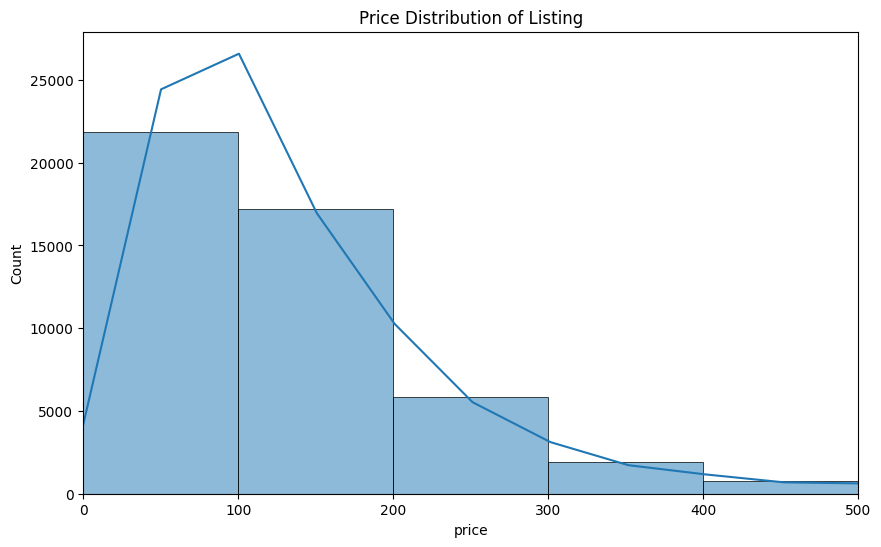

In [8]:
#Price Distribution of Listing
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['price'],bins=100,kde=True)
plt.xlim(0,500)
plt.title("Price Distribution of Listing")
plt.show()


In [ ]:
#REVIEW

The graph shows that the number of listings is higher at lower price ranges, 
whereas the number of expensive listings decreases significantly as the price increases.

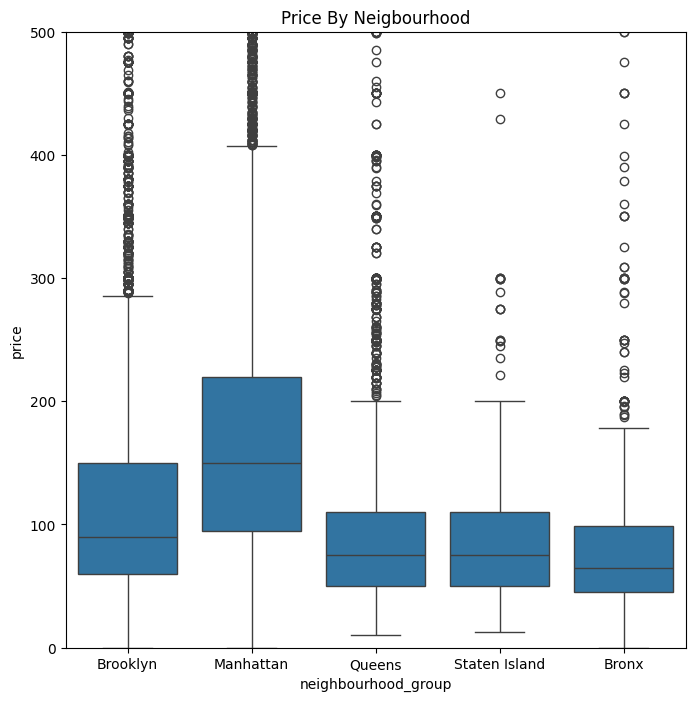

In [11]:
#Price by Neighbourhood

plt.figure(figsize=(8,8))
sns.boxplot(x='neighbourhood_group',y='price',data=df)
plt.ylim(0,500)
plt.title("Price By Neigbourhood")
plt.show()

In [ ]:
#Review

Manhattan is the most expensive with the widest price spread, 
followed by Brooklyn. Queens, Bronx, and Staten Island are more affordable with fewer outliers, 
while Manhattan and Brooklyn have the most high-priced listings.

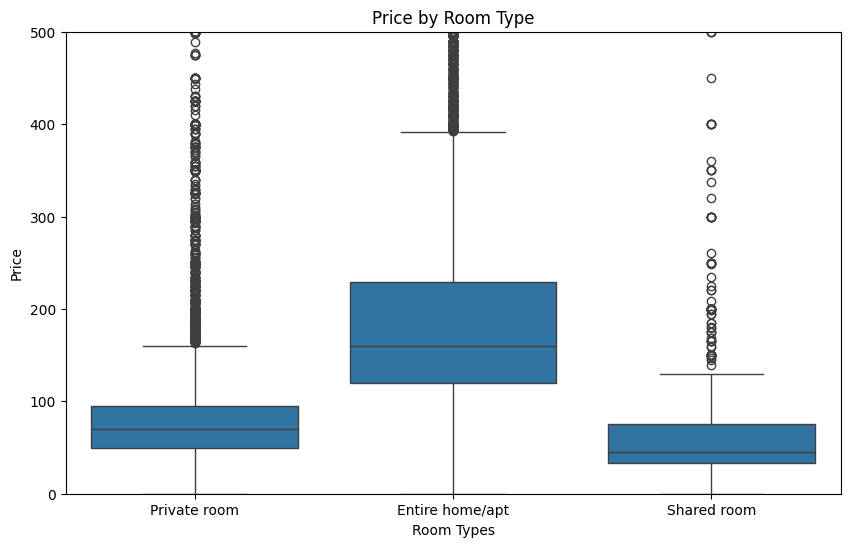

In [15]:
#Price by room type

plt.figure(figsize=(10,6))
sns.boxplot(x='room_type',y='price',data=df)
plt.ylim(0,500)
plt.title("Price by Room Type")
plt.xlabel("Room Types")
plt.ylabel("Price")
plt.show()

In [ ]:
#Review

Entire homes/apartments are the most expensive with the widest price range, 
while private rooms are moderately priced and shared rooms are the cheapest.
Outliers exist across all room types.

In [16]:
#Outlier in Price

outlier = df[df['price']>=1000]
print("Listing Over $1000: ",len(outlier))

Listing Over $1000:  298


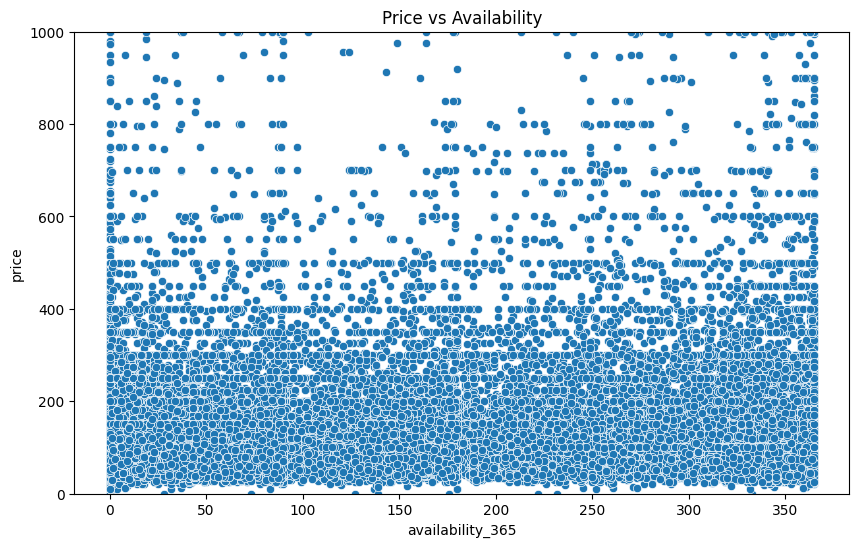

In [19]:
#Price vs Availability

plt.figure(figsize=(10,6))
sns.scatterplot(x='availability_365',y='price',data = df)
plt.title("Price vs Availability")
plt.ylim(0,1000)
plt.show()

In [ ]:
#Review

The Plot shows that availability is higher when the price is low, 
but it gradually decreases as the price increases

In [21]:
################################################################################
#Room Type Analysis
###############################################################################

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


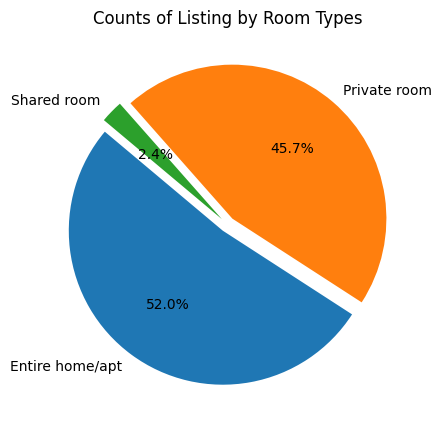

In [61]:
#Count of Listing by Room Types

room_count = df['room_type'].value_counts()
print(room_count)

plt.figure(figsize=(5,5))
plt.pie(room_count, 
        labels=room_count.index,
        autopct='%1.1f%%',
        explode=[0.05]*len(room_count),
        startangle = 140
       )
plt.title("Counts of Listing by Room Types")
plt.show()

In [ ]:
#Review

Most listings are for entire homes/apartments (52%), 
followed closely by private rooms (46%). Shared rooms make up a very small portion (about 2%). 
This shows that guests mainly prefer whole apartments or private rooms, with shared rooms being rare.

Avg Price by Room Type:  room_type
Shared room         70.13
Private room        89.78
Entire home/apt    211.79
Name: price, dtype: float64


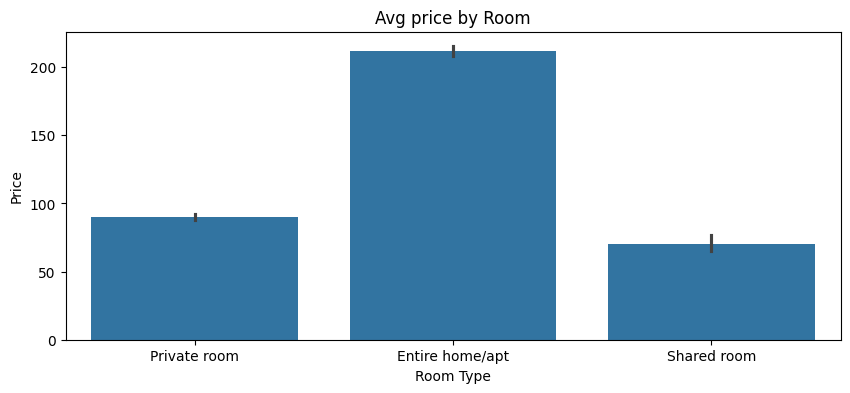

In [43]:
#Avg Price per Room Type

avg_price = df.groupby('room_type')['price'].mean().sort_values().round(2)
print("Avg Price by Room Type: ",avg_price)

plt.figure(figsize=(10,4))
sns.barplot(x='room_type', y='price', estimator='mean', data = df)
plt.title("Avg price by Room")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()


In [ ]:
#Review

Entire homes/apartments have the highest average price, 
followed by private rooms, while shared rooms are the cheapest.

In [49]:
#Minimum Nights By Room Type

min_nights = df.groupby('room_type')['minimum_nights'].min().sort_values()
print('Minimum Nights By Room Type: ',min_nights)

Minimum Nights By Room Type:  room_type
Entire home/apt    1
Private room       1
Shared room        1
Name: minimum_nights, dtype: int64


Availability by Room Types:  room_type
Private room       111.0
Entire home/apt    112.0
Shared room        162.0
Name: availability_365, dtype: float64


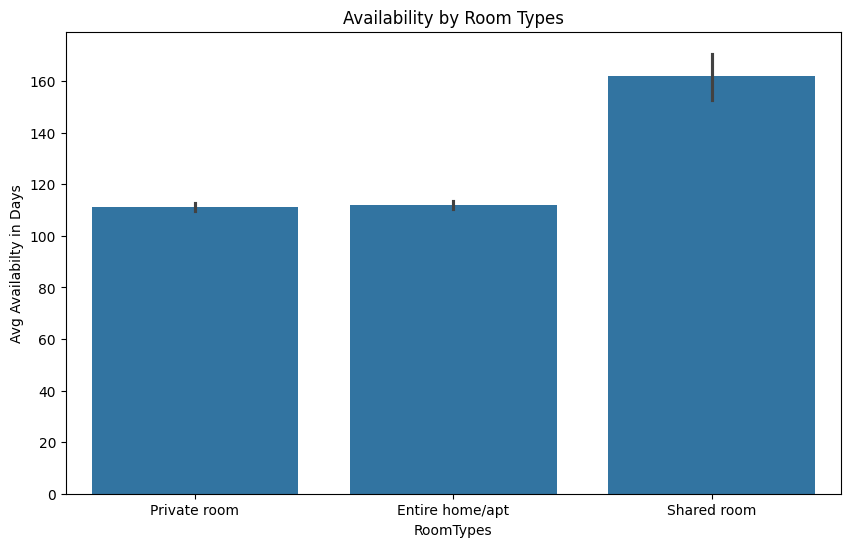

In [53]:
#Availability By Room Types

avail_roomtype = df.groupby('room_type')['availability_365'].mean().sort_values().round()
print('Availability by Room Types: ',avail_roomtype)

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='room_type', y='availability_365', estimator='mean')
plt.title("Availability by Room Types")
plt.xlabel("RoomTypes")
plt.ylabel("Avg Availabilty in Days")
plt.show()


In [ ]:
#Review

Shared rooms have the highest average availability,
while private rooms and entire homes/apartments show similar and lower availability levels


In [62]:
############################################################################################################
#Geographic Analysis
############################################################################################################

Neighbourhood With Most Listings:  neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64


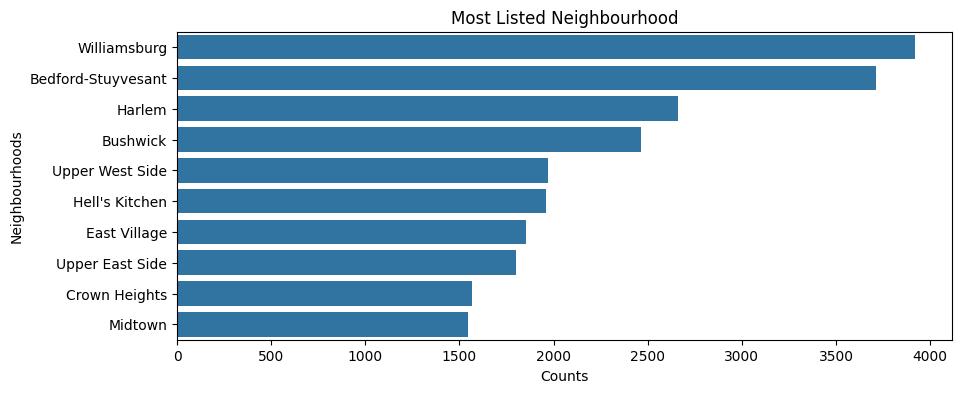

In [70]:
#Neigbourhood With Most Listing

nb_counts = df['neighbourhood'].value_counts().head(10)
print("Neighbourhood With Most Listings: ",nb_counts)

plt.figure(figsize=(10,4))
sns.barplot( x=nb_counts.values, y=nb_counts.index)
plt.title("Most Listed Neighbourhood")
plt.xlabel("Counts")
plt.ylabel("Neighbourhoods")
plt.show()

In [1]:
#Review

This chart highlights how Williamsburg and Bedford-Stuyvesant dominate the rental listings, showing them as the most popular neighbourhoods. 
In contrast, Midtown and Crown Heights lag behind, reflecting relatively lower demand or availability.

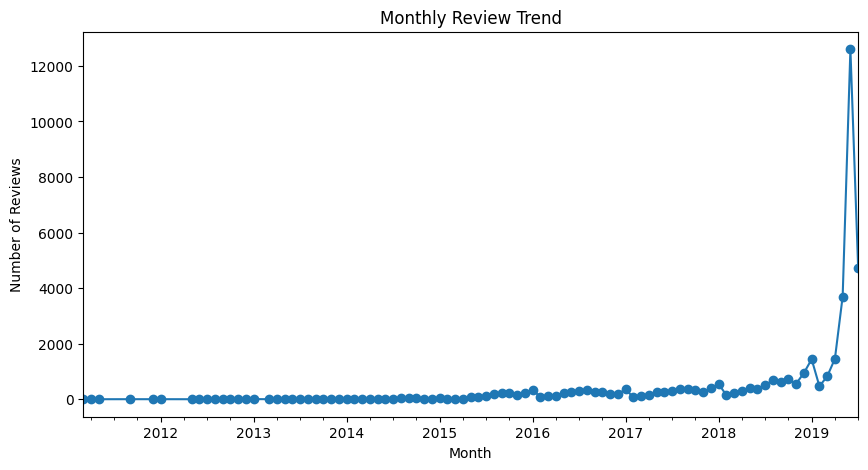

In [81]:
#Monthly Review Trend

df['last_review'] = pd.to_datetime(df['last_review'], dayfirst=True, errors='coerce')

# Group by 
monthly_reviews = df.groupby(df['last_review'].dt.to_period('M')).size()


monthly_reviews.plot(kind='line', figsize=(10,5), marker='o')
plt.title('Monthly Review Trend')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.show()


In [ ]:
#Review

This chart shows that reviews remained relatively low and steady from 2011 to 2017, with gradual growth starting in 2018. 
A massive spike appears in 2019, indicating a sudden surge in user activity and reviews.

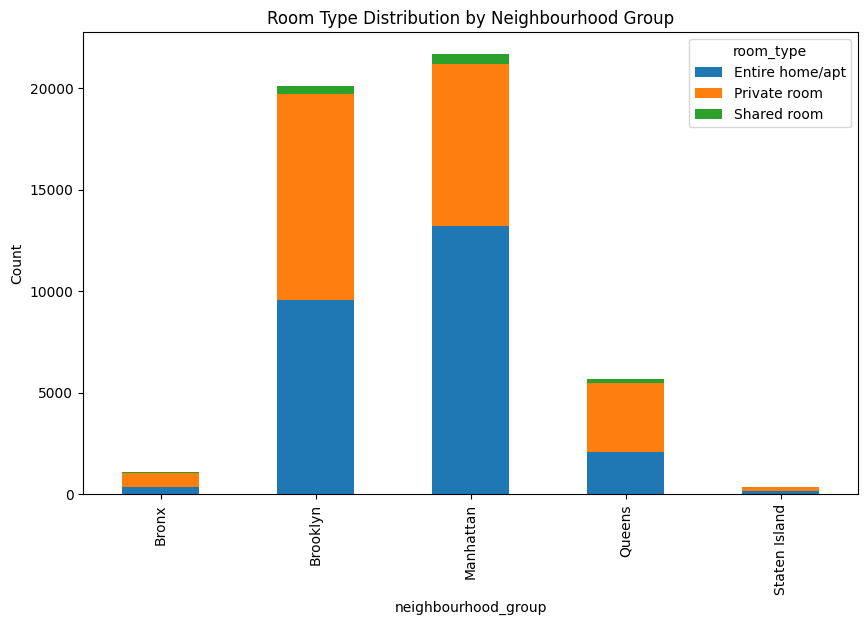

In [6]:
#Room Type Distribution By neighbour Group 


import pandas as pd
df = pd.read_csv("AB_NYC.csv")

room_neigh = df.groupby(['neighbourhood_group','room_type']).size().unstack()
room_neigh.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Room Type Distribution by Neighbourhood Group')
plt.ylabel('Count')
plt.show()


In [ ]:
#Review

This chart shows that Manhattan and Brooklyn dominate in room availability, with entire homes/apartments and private rooms being the most common.
In contrast, Staten Island and the Bronx have very few listings, and shared rooms are the least preferred option across all boroughs.